In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np


In [21]:
product_category_translation = pd.read_csv('product_category_name_translation.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
geolocation= pd.read_csv('olist_geolocation_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [22]:
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"], errors="coerce")
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], errors="coerce")
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"], errors="coerce")


## Gross Merchandise Value (GMV)


In [23]:

gmv = order_items['price'].sum()

print(f"GMV = {gmv:,.0f}")

GMV = 13,591,644


## Monthly Revenue Trend


In [24]:
total_price_per_order = (
    order_items.groupby('order_id')
    .agg(
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        total_amount=('price', lambda x: x.sum())
    )
    .reset_index()
)

total_price_per_order['total_amount'] = (
    total_price_per_order['total_price']
    + total_price_per_order['total_freight']
)

total_price_per_order.head()

,order_id,total_price,total_freight,total_amount
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [25]:
orders_Prices = orders.merge(
    total_price_per_order[['order_id', 'total_price','total_freight']],
    on='order_id',
    how='left'
)

In [26]:
orders_Prices['order_month'] = orders_Prices['order_purchase_timestamp'].dt.to_period('M')

In [27]:
sales_over_time = (
    orders_Prices.groupby('order_month')['total_price']
    .sum()
)
sales_over_time

order_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
2018-10          0.00
Freq: M, Name: total_price, dtype: float64

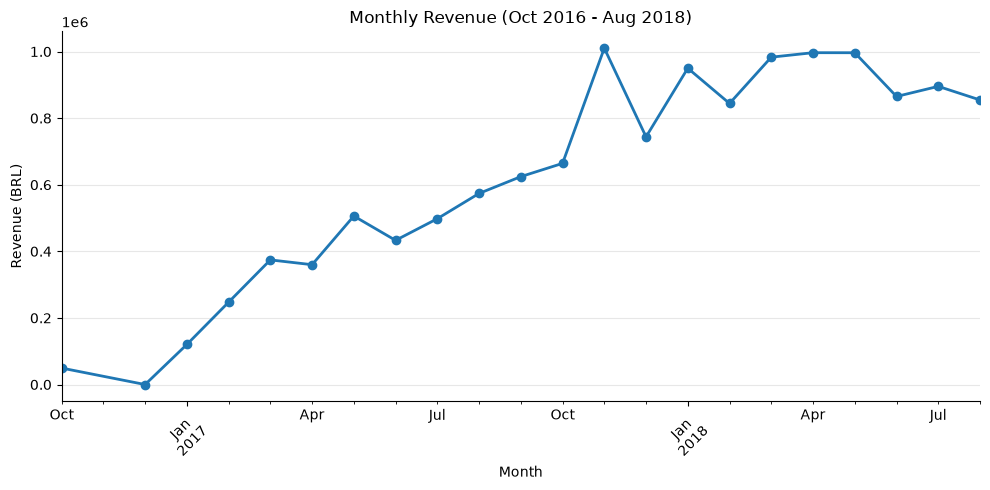

In [28]:
sales_plot = sales_over_time.loc['2016-10':'2018-08']

ax = sales_plot.plot(
    kind='line',
    marker='o',
    linewidth=2,
    figsize=(10,5)
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.title('Monthly Revenue (Oct 2016 - Aug 2018)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Monthly Order Volume Growth


In [29]:
Growth_over_time = (
    orders_Prices.groupby('order_month')['order_id']
    .count().reset_index(name='order_count')
)
Growth_over_time

,order_month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


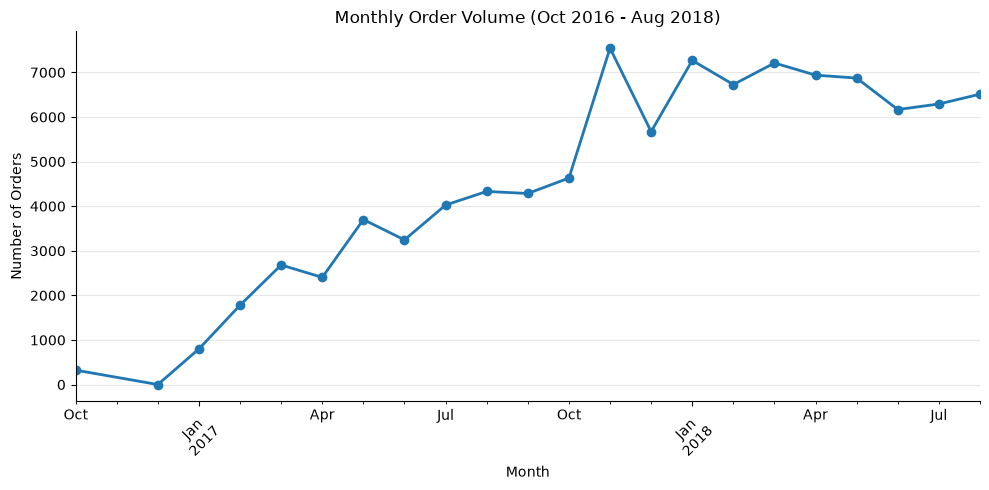

In [30]:

volume_plot = Growth_over_time.set_index('order_month').loc['2016-10':'2018-08']

ax = volume_plot['order_count'].plot(
    kind='line',
    marker='o',
    linewidth=2,
    figsize=(10,5)
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Monthly Order Volume (Oct 2016 - Aug 2018)')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Average Order Value (AOV)


In [31]:
AOV = (
    order_items['price'].sum()
    / order_items['order_id'].nunique()
)

print(f'Average Order Value: {AOV:.2f} BRL')

Average Order Value: 137.75 BRL


## Revenue by Product Category

In [32]:
category_revenue = (
    order_items
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
    .merge(
        product_category_translation,
        on='product_category_name',
        how='left'
    )
)

In [33]:
category_revenue_summary = (
    category_revenue.groupby('product_category_name_english')
    .agg(
        total_revenue=('price', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
)

category_revenue_summary.head(10)

,total_revenue
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


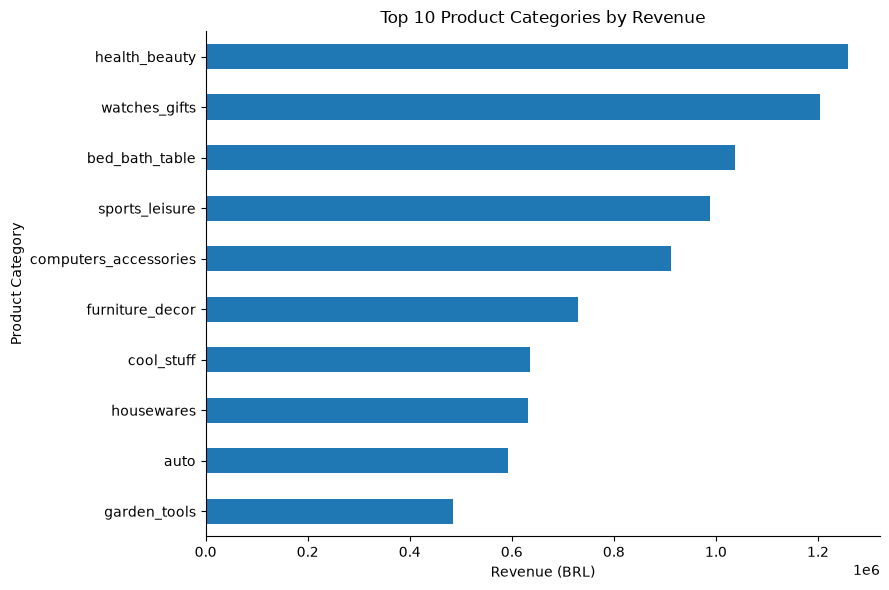

In [34]:

top10 = category_revenue_summary.head(10)

ax = top10.sort_values('total_revenue').plot(
    kind='barh',
    y='total_revenue',
    legend=False,
    figsize=(9,6)
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Revenue (BRL)')
plt.ylabel('Product Category')
plt.title('Top 10 Product Categories by Revenue')

plt.tight_layout()
plt.show()

##  Freight Cost vs. Order Value


In [35]:
orders_Prices[['total_price', 'total_freight']].corr()

,total_price,total_freight
total_price,1.000000,0.412786
total_freight,0.412786,1.000000


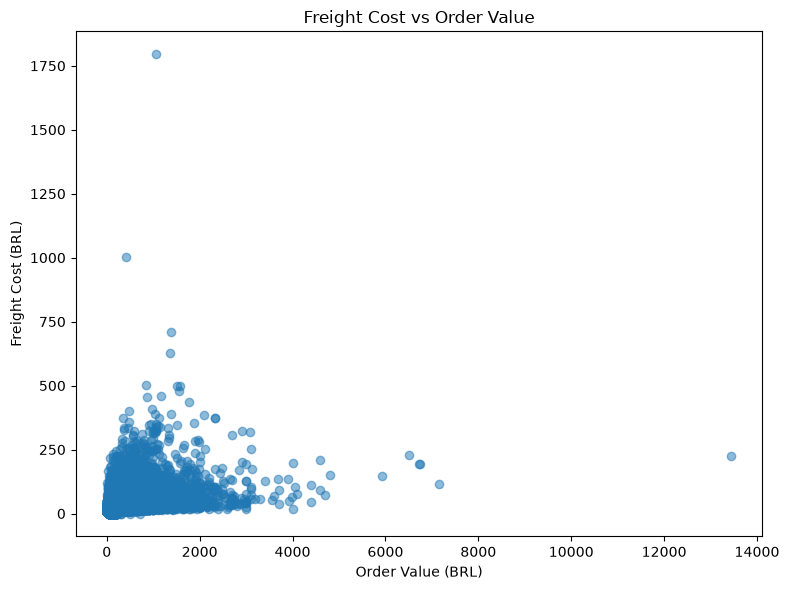

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    orders_Prices['total_price'],
    orders_Prices['total_freight'],
    alpha=0.5
)

plt.xlabel("Order Value (BRL)")
plt.ylabel("Freight Cost (BRL)")
plt.title("Freight Cost vs Order Value")

plt.tight_layout()
plt.show()